<a href="https://colab.research.google.com/github/RothRothRoth/DeepLearning_CNN/blob/main/Road_Sign_Recognition_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Check TensorFlow and GPU

import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [3]:
# Install KaggleHub
!pip install -q kagglehub

In [4]:
from google.colab import drive
import os

# --- 1. Mount Google Drive ---
drive_mount_status = "Not Connected"
try:
    drive.mount('/content/drive')
    drive_mount_status = "Connected"
    print("Google Drive mounted successfully at /content/drive")
except Exception as e:
    print(f"Error mounting Google Drive: {e}")

# --- 2. Define Project Folder and Subdirectories ---
project_name = "Road_Sign_Recognition_CNN"
project_root_path = os.path.join('/content/drive/MyDrive', project_name)

# Define subdirectories relative to the project root
subdirectories = {
    'dataset': ['raw', 'processed', 'test'],
    'models': [],
    'results': ['graphs', 'predictions', 'confusion_matrix'],
    'notebooks': []
}

# --- 3. Create Project Folder and Subdirectories ---
print(f"\nSetting up project folders in: {project_root_path}")

# Check and create project root folder
project_folder_status = "Not Created"
if not os.path.exists(project_root_path):
    os.makedirs(project_root_path)
    project_folder_status = "Created"
    print(f"Project folder '{project_root_path}' created.")
else:
    project_folder_status = "Already exists"
    print(f"Project folder '{project_root_path}' already exists.")

created_folders = []

# Create subdirectories and their nested folders
for parent_dir, children_dirs in subdirectories.items():
    parent_path = os.path.join(project_root_path, parent_dir)
    if not os.path.exists(parent_path):
        os.makedirs(parent_path)
        print(f"  Folder '{parent_path}' created.")
    else:
        print(f"  Folder '{parent_path}' already exists.")
    created_folders.append(parent_path)

    for child_dir in children_dirs:
        child_path = os.path.join(parent_path, child_dir)
        if not os.path.exists(child_path):
            os.makedirs(child_path)
            print(f"    Subfolder '{child_path}' created.")
        else:
            print(f"    Subfolder '{child_path}' already exists.")
        created_folders.append(child_path)

# --- 4. Print full paths of all created folders ---
print("\n--- Full Paths of Project Folders ---")
print(f"Project Root: {project_root_path}")
for folder_path in created_folders:
    print(f"- {folder_path}")

# --- 5. Simple Summary ---
print("\n--- Setup Summary ---")
print(f"Google Drive: {drive_mount_status}")
print(f"Project folder: {project_folder_status}")
print(f"Dataset folder: {'Ready' if os.path.exists(os.path.join(project_root_path, 'dataset')) else 'Not Ready'}")
print(f"Models folder: {'Ready' if os.path.exists(os.path.join(project_root_path, 'models')) else 'Not Ready'}")
print(f"Results folder: {'Ready' if os.path.exists(os.path.join(project_root_path, 'results')) else 'Not Ready'}")


Error mounting Google Drive: mount failed

Setting up project folders in: /content/drive/MyDrive/Road_Sign_Recognition_CNN
Project folder '/content/drive/MyDrive/Road_Sign_Recognition_CNN' created.
  Folder '/content/drive/MyDrive/Road_Sign_Recognition_CNN/dataset' created.
    Subfolder '/content/drive/MyDrive/Road_Sign_Recognition_CNN/dataset/raw' created.
    Subfolder '/content/drive/MyDrive/Road_Sign_Recognition_CNN/dataset/processed' created.
    Subfolder '/content/drive/MyDrive/Road_Sign_Recognition_CNN/dataset/test' created.
  Folder '/content/drive/MyDrive/Road_Sign_Recognition_CNN/models' created.
  Folder '/content/drive/MyDrive/Road_Sign_Recognition_CNN/results' created.
    Subfolder '/content/drive/MyDrive/Road_Sign_Recognition_CNN/results/graphs' created.
    Subfolder '/content/drive/MyDrive/Road_Sign_Recognition_CNN/results/predictions' created.
    Subfolder '/content/drive/MyDrive/Road_Sign_Recognition_CNN/results/confusion_matrix' created.
  Folder '/content/drive/

In [5]:
import kagglehub
import os

# Download the Cambodia Traffic Signs Dataset
dataset_path = kagglehub.dataset_download(
    "sophalratitya/cambodia-traffic-signs-dataset"
)

print("Dataset downloaded!")
print("Dataset location:")
print(dataset_path)

print("\nFiles:")
for item in os.listdir(dataset_path):
    print("-", item)

100%|██████████| 1.53G/1.53G [00:24<00:00, 66.6MB/s]

Extracting files...


Dataset downloaded!
Dataset location:
/root/.cache/kagglehub/datasets/sophalratitya/cambodia-traffic-signs-dataset/versions/1

Files:
- images
- labels
- via.html
- data


In [6]:
# Inspect the Cambodia Traffic Signs Dataset

import os

print("DATASET STRUCTURE")
print("=" * 50)

for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, "").count(os.sep)

    # Don't print too deeply
    if level <= 2:
        indent = "  " * level
        print(f"{indent}{os.path.basename(root)}/")

        for file in files[:10]:
            print(f"{indent}  ├── {file}")

        if len(files) > 10:
            print(f"{indent}  └── ... ({len(files)} files total)")

DATASET STRUCTURE
1/
  ├── via.html
  images/
    ├── GX010112.MP4_snapshot_03.38.617.jpg
    ├── GX020116.MP4_snapshot_01.53.896.jpg
    ├── GX010276.MP4_snapshot_15.31.053.JPG
    ├── NR6_136.jpg
    ├── GX020113.MP4_snapshot_01.44.389.jpg
    ├── NR1_11.jpg
    ├── GX010272.MP4_snapshot_18.18.803.JPG
    ├── GX010114.MP4_snapshot_03.37.732.jpg
    ├── GX020274.MP4_snapshot_22.42.353.JPG
    ├── GX020275.MP4_snapshot_01.23.689.JPG
    └── ... (2766 files total)
  labels/
    ├── GX020116.MP4_snapshot_08.06.293.txt
    ├── NR5_117.txt
    ├── NR5_41.txt
    ├── NR5_15.txt
    ├── NR1_177.txt
    ├── NR6_447.txt
    ├── GX010238.MP4_snapshot_11.59.950.txt
    ├── GX010276.MP4_snapshot_13.42.898.txt
    ├── NR6_303.txt
    ├── GX010118.MP4_snapshot_07.05.369.txt
    └── ... (2757 files total)
  data/
    ├── CAM_TSR_v3_json_state.json
    ├── Traffic_Sign.yaml
    ├── CAM_TSR_json.json
    ├── CAM_TSR_csv.csv
    ├── Traffic_Sign_class.yaml
    ├── Traffic_Sign_name.yaml
    ├── CAM_TSR

In [7]:
# Inspect the dataset labels and class information

import os
from collections import Counter

labels_path = os.path.join(dataset_path, "labels")

# Count class IDs
class_counts = Counter()

label_files = [
    f for f in os.listdir(labels_path)
    if f.endswith(".txt")
]

for filename in label_files:
    filepath = os.path.join(labels_path, filename)

    with open(filepath, "r") as f:
        for line in f:
            parts = line.strip().split()

            if len(parts) >= 1:
                class_id = parts[0]
                class_counts[class_id] += 1

print("Number of label files:", len(label_files))
print("\nClass IDs found:")
for class_id, count in sorted(class_counts.items()):
    print(f"Class {class_id}: {count} annotations")

Number of label files: 2757

Class IDs found:
Class 0: 3491 annotations


In [8]:
# Read the traffic sign class names from the YAML file

import yaml

yaml_path = os.path.join(dataset_path, "data", "Traffic_Sign.yaml")

print("YAML file:", yaml_path)

with open(yaml_path, "r") as f:
    data_yaml = yaml.safe_load(f)

print("\nDataset information:")
print(data_yaml)

YAML file: /root/.cache/kagglehub/datasets/sophalratitya/cambodia-traffic-signs-dataset/versions/1/data/Traffic_Sign.yaml

Dataset information:
{'path': 'C:/srt/raw_data/datasets', 'train': 'images/train', 'val': 'images/val', 'test': None, 'names': {0: 'Traffic Sign'}, 'download': None}


In [9]:
# Inspect the annotation/data files to find the actual traffic sign names

import os
import pandas as pd

data_path = os.path.join(dataset_path, "data")

print("Files inside data folder:")
print("=" * 60)

for file in os.listdir(data_path):
    file_path = os.path.join(data_path, file)
    size = os.path.getsize(file_path) / (1024 * 1024)
    print(f"{file:35s} {size:.2f} MB")

Files inside data folder:
CAM_TSR_v3_json_state.json          0.73 MB
Traffic_Sign.yaml                   0.00 MB
CAM_TSR_json.json                   0.43 MB
CAM_TSR_csv.csv                     0.31 MB
Traffic_Sign_class.yaml             0.00 MB
Traffic_Sign_name.yaml              0.00 MB
CAM_TSR_v2_json.json                0.69 MB
CAM_TSR_v2.json                     0.76 MB
CAM_TSR.json                        0.48 MB
CAM_TSR_attributes.json             0.00 MB
CAM_TSR_v3.json                     1.05 MB
CAM_TSR_v3_json.json                0.95 MB


In [10]:
# Inspect CSV files

for file in os.listdir(data_path):
    if file.lower().endswith(".csv"):
        file_path = os.path.join(data_path, file)

        print("\n" + "=" * 70)
        print("FILE:", file)
        print("=" * 70)

        try:
            df = pd.read_csv(file_path)

            print("Shape:", df.shape)
            print("Columns:")
            print(list(df.columns))

            print("\nFirst 5 rows:")
            display(df.head())

        except Exception as e:
            print("Could not read:", e)


FILE: CAM_TSR_csv.csv
Shape: (1613, 7)
Columns:
['filename', 'file_size', 'file_attributes', 'region_count', 'region_id', 'region_shape_attributes', 'region_attributes']

First 5 rows:


,filename,file_size,file_attributes,region_count,region_id,region_shape_attributes,region_attributes
0,GX010109.MP4_snapshot_00.10.234.jpg,258867,{},2,0,"{""name"":""rect"",""x"":2735,""y"":648,""width"":175,""h...","{""Object"":""Traffic Sign"",""Class"":""Warning"",""Na..."
1,GX010109.MP4_snapshot_00.10.234.jpg,258867,{},2,1,"{""name"":""rect"",""x"":2749,""y"":807,""width"":153,""h...","{""Object"":""Traffic Sign"",""Class"":""Prohibitory""..."
2,GX010109.MP4_snapshot_00.18.192.jpg,276893,{},1,0,"{""name"":""rect"",""x"":2989,""y"":702,""width"":237,""h...","{""Object"":""Traffic Sign"",""Class"":""Warning"",""Na..."
3,GX010109.MP4_snapshot_00.21.104.jpg,273717,{},1,0,"{""name"":""rect"",""x"":3264,""y"":779,""width"":136,""h...","{""Object"":""Traffic Sign"",""Class"":""Service"",""Na..."
4,GX010109.MP4_snapshot_00.24.905.jpg,275907,{},1,0,"{""name"":""rect"",""x"":2625,""y"":870,""width"":109,""h...","{""Object"":""Traffic Sign"",""Class"":""Service"",""Na..."


In [11]:
# Show all CSV files and their columns

for file in os.listdir(data_path):
    if file.lower().endswith(".csv"):
        file_path = os.path.join(data_path, file)

        df = pd.read_csv(file_path)

        print("\n" + "=" * 60)
        print(file)
        print("=" * 60)
        print("Shape:", df.shape)
        print("Columns:", list(df.columns))
        display(df.head(10))


CAM_TSR_csv.csv
Shape: (1613, 7)
Columns: ['filename', 'file_size', 'file_attributes', 'region_count', 'region_id', 'region_shape_attributes', 'region_attributes']


,filename,file_size,file_attributes,region_count,region_id,region_shape_attributes,region_attributes
0,GX010109.MP4_snapshot_00.10.234.jpg,258867,{},2,0,"{""name"":""rect"",""x"":2735,""y"":648,""width"":175,""h...","{""Object"":""Traffic Sign"",""Class"":""Warning"",""Na..."
1,GX010109.MP4_snapshot_00.10.234.jpg,258867,{},2,1,"{""name"":""rect"",""x"":2749,""y"":807,""width"":153,""h...","{""Object"":""Traffic Sign"",""Class"":""Prohibitory""..."
2,GX010109.MP4_snapshot_00.18.192.jpg,276893,{},1,0,"{""name"":""rect"",""x"":2989,""y"":702,""width"":237,""h...","{""Object"":""Traffic Sign"",""Class"":""Warning"",""Na..."
3,GX010109.MP4_snapshot_00.21.104.jpg,273717,{},1,0,"{""name"":""rect"",""x"":3264,""y"":779,""width"":136,""h...","{""Object"":""Traffic Sign"",""Class"":""Service"",""Na..."
4,GX010109.MP4_snapshot_00.24.905.jpg,275907,{},1,0,"{""name"":""rect"",""x"":2625,""y"":870,""width"":109,""h...","{""Object"":""Traffic Sign"",""Class"":""Service"",""Na..."
5,GX010109.MP4_snapshot_00.28.509.jpg,273867,{},1,0,"{""name"":""rect"",""x"":2668,""y"":877,""width"":106,""h...","{""Object"":""Traffic Sign"",""Class"":""Service"",""Na..."
6,GX010109.MP4_snapshot_00.44.749.jpg,269476,{},1,0,"{""name"":""rect"",""x"":3196,""y"":733,""width"":188,""h...","{""Object"":""Traffic Sign"",""Class"":""Warning"",""Na..."
7,GX010109.MP4_snapshot_00.48.325.jpg,287723,{},1,0,"{""name"":""rect"",""x"":3495,""y"":709,""width"":178,""h...","{""Object"":""Traffic Sign"",""Class"":""Service"",""Na..."
8,GX010109.MP4_snapshot_00.56.887.jpg,64436,{},2,0,"{""name"":""rect"",""x"":2906,""y"":811,""width"":153,""h...","{""Object"":""Traffic Sign"",""Class"":""Prohibitory""..."
9,GX010109.MP4_snapshot_00.56.887.jpg,64436,{},2,1,"{""name"":""rect"",""x"":2344,""y"":957,""width"":53,""he...","{""Object"":""Traffic Sign"",""Class"":""Service"",""Na..."


In [12]:
# Inspect JSON files for traffic-sign information

import json

for file in os.listdir(data_path):
    if file.lower().endswith(".json"):
        file_path = os.path.join(data_path, file)

        print("\n" + "=" * 60)
        print("JSON:", file)
        print("=" * 60)

        try:
            with open(file_path, "r", encoding="utf-8") as f:
                data = json.load(f)

            print("Type:", type(data))

            if isinstance(data, dict):
                print("Top-level keys:", list(data.keys())[:30])

        except Exception as e:
            print("Error:", e)


JSON: CAM_TSR_v3_json_state.json
Type: <class 'dict'>
Top-level keys: ['GX010109.MP4_snapshot_00.10.234.jpg1255446', 'GX010109.MP4_snapshot_00.18.192.jpg1346307', 'GX010109.MP4_snapshot_00.21.104.jpg1329723', 'GX010109.MP4_snapshot_00.24.905.jpg1355964', 'GX010109.MP4_snapshot_00.28.509.jpg1351471', 'GX010109.MP4_snapshot_00.44.749.jpg1328781', 'GX010109.MP4_snapshot_00.48.325.jpg1388990', 'GX010109.MP4_snapshot_00.56.887.jpg1319329', 'GX010109.MP4_snapshot_00.58.528.jpg1325602', 'GX010109.MP4_snapshot_01.22.517.jpg1172882', 'GX010109.MP4_snapshot_01.29.119.jpg1306733', 'GX010109.MP4_snapshot_01.46.569.jpg1342873', 'GX010109.MP4_snapshot_01.57.570.jpg1227035', 'GX010109.MP4_snapshot_01.58.201.jpg1250438', 'GX010109.MP4_snapshot_02.06.740.jpg1411540', 'GX010109.MP4_snapshot_02.10.370.jpg1320905', 'GX010109.MP4_snapshot_02.19.105.jpg1361603', 'GX010109.MP4_snapshot_02.23.541.jpg1318609', 'GX010109.MP4_snapshot_02.42.769.jpg1222147', 'GX010109.MP4_snapshot_02.50.271.jpg1286153', 'GX01010

In [13]:
# Inspect one real image annotation

import json
import os
from pprint import pprint

json_path = os.path.join(data_path, "CAM_TSR_v3_json.json")

with open(json_path, "r", encoding="utf-8") as f:
    annotations = json.load(f)

print("Number of annotated images:", len(annotations))

# Get the first image
first_image = next(iter(annotations))

print("\nFirst image:")
print(first_image)

print("\nIts annotation:")
pprint(annotations[first_image])

Number of annotated images: 2757

First image:
GX010109.MP4_snapshot_00.10.234.jpg1255446

Its annotation:
{'file_attributes': {},
 'filename': 'GX010109.MP4_snapshot_00.10.234.jpg',
 'regions': [{'region_attributes': {'Class': 'Warning',
                                    'Name': 'CHILDREN CROSSING',
                                    'Object': 'Traffic Sign',
                                    'Status': 'Good'},
              'shape_attributes': {'height': 156,
                                   'name': 'rect',
                                   'width': 162,
                                   'x': 2744,
                                   'y': 655}},
             {'region_attributes': {'Class': 'Prohibitory',
                                    'Name': '40 SPEED LIMIT',
                                    'Object': 'Traffic Sign',
                                    'Status': 'Good'},
              'shape_attributes': {'height': 132,
                                   'name': 'rec

In [14]:
# Find all traffic sign names and count how many annotations each has

from collections import Counter

sign_counts = Counter()

for image_id, annotation in annotations.items():
    for region in annotation.get("regions", []):
        attributes = region.get("region_attributes", {})
        sign_name = attributes.get("Name")

        if sign_name:
            sign_counts[sign_name] += 1

print("Total different sign names:", len(sign_counts))
print("\nTraffic sign classes:")
print("=" * 60)

for sign_name, count in sign_counts.most_common():
    print(f"{sign_name:40s} {count:5d}")

Total different sign names: 49

Traffic sign classes:
KM POST                                    738
KEEP RIGHT                                 327
CHILDREN CROSSING                          188
PEDESTRAIN CR AREA                         186
ROAD JUNCTION ON THE RIGHT                 155
SLOW DOWN                                  152
DIRECTION                                  152
PEDESTRAIN CROSSING                        120
UNDEFINED                                  117
PRIORITY ROAD                              109
ROAD JUNCTION ON THE LEFT                  107
NO UTURN                                   106
40 SPEED LIMIT                              94
NO ENTRY                                    57
LEFT BEND                                   54
HOSPITAL                                    53
END SPEED LIMIT                             52
NO HORN                                     52
NO PARKING                                  50
60 SPEED LIMIT                              48
RIGHT 

In [15]:
# Clean the incorrectly generated processed dataset

import shutil
import os

processed_path = "/content/drive/MyDrive/Road_Sign_Recognition_CNN/dataset/processed"

if os.path.exists(processed_path):
    shutil.rmtree(processed_path)

os.makedirs(processed_path, exist_ok=True)

print("Processed dataset cleaned.")
print("Ready to create the correct 26-class dataset.")

Processed dataset cleaned.
Ready to create the correct 26-class dataset.


In [16]:
# Define the 26 traffic sign classes for our CNN

selected_classes = [
    "KM POST",
    "KEEP RIGHT",
    "CHILDREN CROSSING",
    "PEDESTRAIN CR AREA",
    "ROAD JUNCTION ON THE RIGHT",
    "SLOW DOWN",
    "DIRECTION",
    "PEDESTRAIN CROSSING",
    "PRIORITY ROAD",
    "ROAD JUNCTION ON THE LEFT",
    "NO UTURN",
    "40 SPEED LIMIT",
    "NO ENTRY",
    "LEFT BEND",
    "HOSPITAL",
    "END SPEED LIMIT",
    "NO HORN",
    "NO PARKING",
    "60 SPEED LIMIT",
    "RIGHT BEND",
    "U TURN",
    "CROSS ROAD",
    "STAGGERED JUNCTION, RL",
    "80 SPEED LIMIT",
    "30 SPEED LIMIT",
    "CARRIAGE WAY NARROWS"
]

print("Number of selected classes:", len(selected_classes))

for i, name in enumerate(selected_classes):
    print(f"{i:02d} → {name}")

Number of selected classes: 26
00 → KM POST
01 → KEEP RIGHT
02 → CHILDREN CROSSING
03 → PEDESTRAIN CR AREA
04 → ROAD JUNCTION ON THE RIGHT
05 → SLOW DOWN
06 → DIRECTION
07 → PEDESTRAIN CROSSING
08 → PRIORITY ROAD
09 → ROAD JUNCTION ON THE LEFT
10 → NO UTURN
11 → 40 SPEED LIMIT
12 → NO ENTRY
13 → LEFT BEND
14 → HOSPITAL
15 → END SPEED LIMIT
16 → NO HORN
17 → NO PARKING
18 → 60 SPEED LIMIT
19 → RIGHT BEND
20 → U TURN
21 → CROSS ROAD
22 → STAGGERED JUNCTION, RL
23 → 80 SPEED LIMIT
24 → 30 SPEED LIMIT
25 → CARRIAGE WAY NARROWS


Image: GX010109.MP4_snapshot_00.10.234.jpg
Path: /root/.cache/kagglehub/datasets/sophalratitya/cambodia-traffic-signs-dataset/versions/1/images/GX010109.MP4_snapshot_00.10.234.jpg
Image loaded: True
Image size: (2160, 3840, 3)

Regions found: 2

Region 0
Sign: CHILDREN CROSSING
Class: Warning
Object: Traffic Sign
Shape: {'name': 'rect', 'x': 2744, 'y': 655, 'width': 162, 'height': 156}
Crop size: (156, 162, 3)


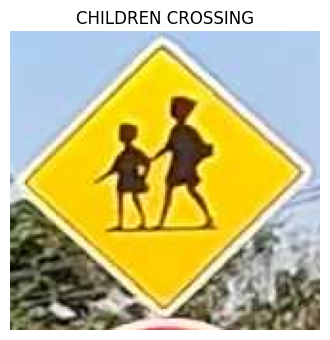

✅ CROP SUCCESSFUL!


In [17]:
# ============================================
# TEST ONE TRAFFIC SIGN CROP
# ============================================

import os
import cv2
import matplotlib.pyplot as plt

images_path = os.path.join(dataset_path, "images")

# Get first annotated image
image_id = next(iter(annotations))
annotation = annotations[image_id]

image_name = annotation["filename"]
image_path = os.path.join(images_path, image_name)

print("Image:", image_name)
print("Path:", image_path)

# Load image
image = cv2.imread(image_path)

print("Image loaded:", image is not None)

if image is not None:

    print("Image size:", image.shape)

    print("\nRegions found:", len(annotation["regions"]))

    # Look at each region
    for i, region in enumerate(annotation["regions"]):

        attrs = region["region_attributes"]
        shape = region["shape_attributes"]

        print(f"\nRegion {i}")
        print("Sign:", attrs.get("Name"))
        print("Class:", attrs.get("Class"))
        print("Object:", attrs.get("Object"))
        print("Shape:", shape)

        # Only test selected classes
        if attrs.get("Name") in selected_classes:

            x = int(shape["x"])
            y = int(shape["y"])
            w = int(shape["width"])
            h = int(shape["height"])

            crop = image[y:y+h, x:x+w]

            print("Crop size:", crop.shape)

            if crop.size > 0:

                crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)

                plt.figure(figsize=(4,4))
                plt.imshow(crop_rgb)
                plt.title(attrs["Name"])
                plt.axis("off")
                plt.show()

                print("✅ CROP SUCCESSFUL!")
                break

In [18]:
# ============================================
# BUILD THE FULL CNN DATASET
# ============================================

import os
import cv2
import shutil
from collections import Counter

images_path = os.path.join(dataset_path, "images")
processed_path = "/content/drive/MyDrive/Road_Sign_Recognition_CNN/dataset/processed"

# Clear old processed dataset
if os.path.exists(processed_path):
    shutil.rmtree(processed_path)

os.makedirs(processed_path, exist_ok=True)

saved_counts = Counter()
skipped = 0

for image_id, annotation in annotations.items():

    image_name = annotation["filename"]
    image_path = os.path.join(images_path, image_name)

    if not os.path.isfile(image_path):
        skipped += 1
        continue

    image = cv2.imread(image_path)

    if image is None:
        skipped += 1
        continue

    for region_index, region in enumerate(annotation.get("regions", [])):

        attrs = region.get("region_attributes", {})
        shape = region.get("shape_attributes", {})

        sign_name = attrs.get("Name")

        # Keep only our 26 classes
        if sign_name not in selected_classes:
            continue

        x = int(shape["x"])
        y = int(shape["y"])
        w = int(shape["width"])
        h = int(shape["height"])

        # Make sure the box is valid
        if w <= 0 or h <= 0:
            continue

        # Crop
        crop = image[y:y+h, x:x+w]

        if crop.size == 0:
            continue

        # Resize
        crop = cv2.resize(crop, (64, 64))

        # Folder name
        folder_name = (
            sign_name
            .replace(" ", "_")
            .replace(",", "")
        )

        class_folder = os.path.join(
            processed_path,
            folder_name
        )

        os.makedirs(class_folder, exist_ok=True)

        # Unique filename
        base_name = os.path.splitext(image_name)[0]
        filename = f"{base_name}_{region_index}.jpg"

        output_path = os.path.join(
            class_folder,
            filename
        )

        if cv2.imwrite(output_path, crop):
            saved_counts[sign_name] += 1


# ============================================
# SHOW RESULTS
# ============================================

print("=" * 60)
print("CNN DATASET CREATED")
print("=" * 60)

print("Total images:", sum(saved_counts.values()))
print("Images skipped:", skipped)
print("Classes created:", len(saved_counts))

print("\nImages per class:")
print("-" * 60)

for name in selected_classes:
    print(f"{name:40s} {saved_counts[name]}")

print("\nSaved to:")
print(processed_path)

CNN DATASET CREATED
Total images: 3070
Images skipped: 0
Classes created: 26

Images per class:
------------------------------------------------------------
KM POST                                  738
KEEP RIGHT                               327
CHILDREN CROSSING                        188
PEDESTRAIN CR AREA                       186
ROAD JUNCTION ON THE RIGHT               155
SLOW DOWN                                152
DIRECTION                                152
PEDESTRAIN CROSSING                      120
PRIORITY ROAD                            109
ROAD JUNCTION ON THE LEFT                107
NO UTURN                                 106
40 SPEED LIMIT                           94
NO ENTRY                                 57
LEFT BEND                                54
HOSPITAL                                 53
END SPEED LIMIT                          52
NO HORN                                  52
NO PARKING                               50
60 SPEED LIMIT                          

In [19]:
# ============================================
# LOAD CNN DATASET
# ============================================

import tensorflow as tf

DATA_DIR = "/content/drive/MyDrive/Road_Sign_Recognition_CNN/dataset/processed"

IMG_SIZE = (64, 64)
BATCH_SIZE = 32
SEED = 42

# 80% training
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

# 20% validation
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

class_names = train_ds.class_names

print("\n======================================")
print("DATASET LOADED")
print("======================================")
print("Number of classes:", len(class_names))
print("Training batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Validation batches:", tf.data.experimental.cardinality(val_ds).numpy())

print("\nClasses:")
for i, name in enumerate(class_names):
    print(f"{i:02d} → {name}")

Found 3070 files belonging to 26 classes.
Using 2456 files for training.
Found 3070 files belonging to 26 classes.
Using 614 files for validation.

DATASET LOADED
Number of classes: 26
Training batches: 77
Validation batches: 20

Classes:
00 → 30_SPEED_LIMIT
01 → 40_SPEED_LIMIT
02 → 60_SPEED_LIMIT
03 → 80_SPEED_LIMIT
04 → CARRIAGE_WAY_NARROWS
05 → CHILDREN_CROSSING
06 → CROSS_ROAD
07 → DIRECTION
08 → END_SPEED_LIMIT
09 → HOSPITAL
10 → KEEP_RIGHT
11 → KM_POST
12 → LEFT_BEND
13 → NO_ENTRY
14 → NO_HORN
15 → NO_PARKING
16 → NO_UTURN
17 → PEDESTRAIN_CROSSING
18 → PEDESTRAIN_CR_AREA
19 → PRIORITY_ROAD
20 → RIGHT_BEND
21 → ROAD_JUNCTION_ON_THE_LEFT
22 → ROAD_JUNCTION_ON_THE_RIGHT
23 → SLOW_DOWN
24 → STAGGERED_JUNCTION_RL
25 → U_TURN


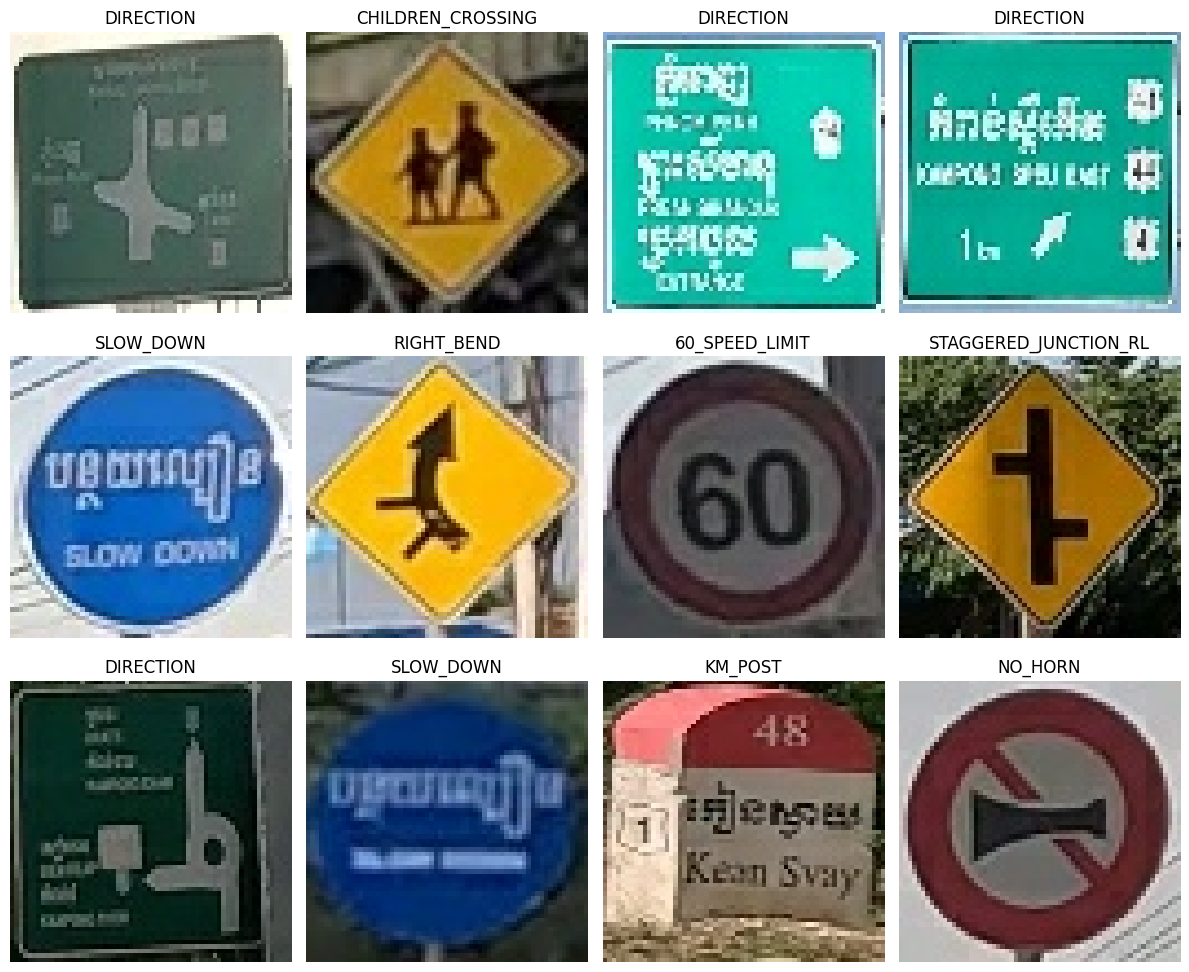

In [20]:
# ============================================
# VISUALIZE TRAINING IMAGES
# ============================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))

for images, labels in train_ds.take(1):

    for i in range(12):

        ax = plt.subplot(3, 4, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i].numpy()])

        plt.axis("off")

plt.tight_layout()
plt.show()

In [21]:
# ============================================
# BUILD CNN MODEL
# ============================================

from tensorflow.keras import layers, models

num_classes = len(class_names)

model = models.Sequential([

    # Input
    layers.Input(shape=(64, 64, 3)),

    # Block 1
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 2
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 3
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Classification
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 29, 29, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 26)             │         3,354 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 687,450 (2.62 MB)

 Trainable params: 687,002 (2.62 MB)

 Non-trainable params: 448 (1.75 KB)

In [22]:

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("CNN model compiled successfully!")

CNN model compiled successfully!


In [23]:
# ============================================
# TRAIN CNN MODEL
# ============================================

EPOCHS = 25

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/25
77/77 ━━━━━━━━━━━━━━━━━━━━ 13s 76ms/step - accuracy: 0.6189 - loss: 1.5544 - val_accuracy: 0.8827 - val_loss: 0.7269
Epoch 2/25
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8331 - loss: 0.5881 - val_accuracy: 0.9560 - val_loss: 0.1905
Epoch 3/25
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8921 - loss: 0.3776 - val_accuracy: 0.9707 - val_loss: 0.1305
Epoch 4/25
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9108 - loss: 0.3128 - val_accuracy: 0.9707 - val_loss: 0.1320
Epoch 5/25
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9397 - loss: 0.2033 - val_accuracy: 0.9739 - val_loss: 0.1133
Epoch 6/25
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9458 - loss: 0.1640 - val_accuracy: 0.9805 - val_loss: 0.1199
Epoch 7/25
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9528 - loss: 0.1508 - val_accuracy: 0.9674 - val_loss: 0.1355
Epoch 8/25
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9585 - loss: 0.1423 - val_accuracy: 0.9739 - val_

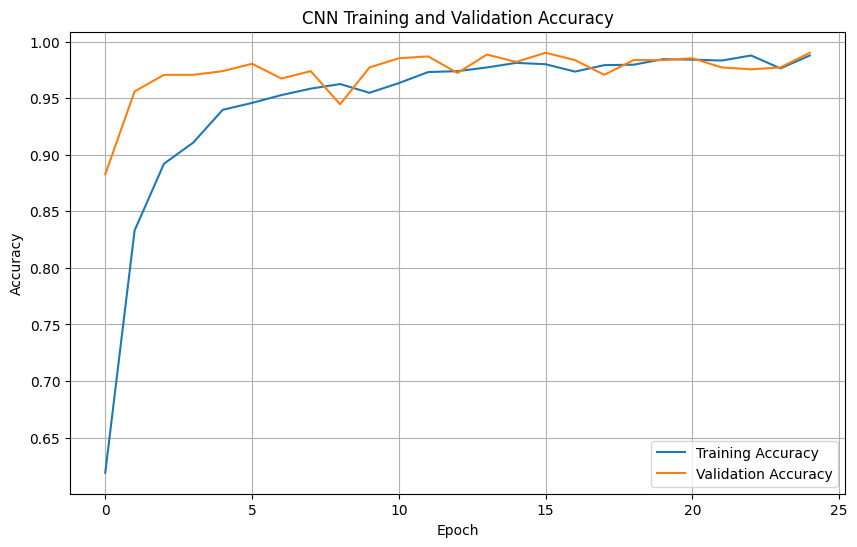

In [24]:
# ============================================
# TRAINING & VALIDATION ACCURACY
# ============================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("CNN Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

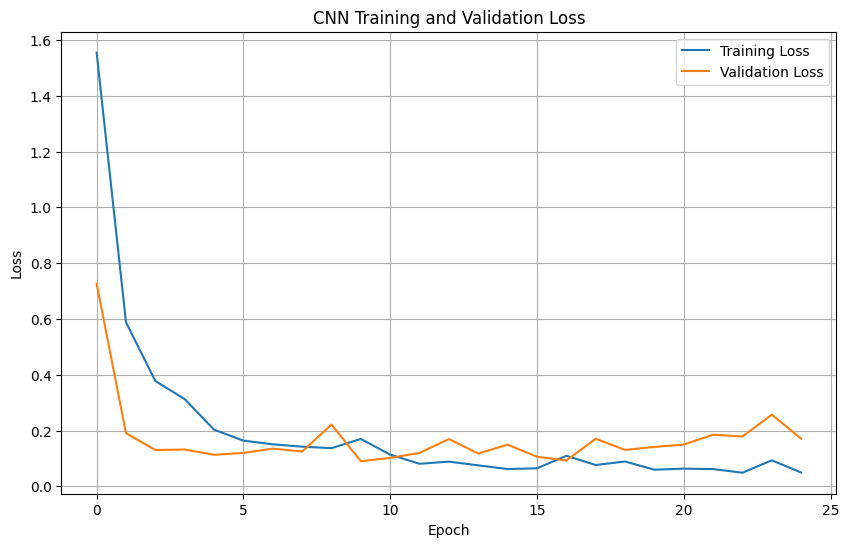

In [25]:
# ============================================
# TRAINING & VALIDATION LOSS
# ============================================

plt.figure(figsize=(10, 6))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("CNN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

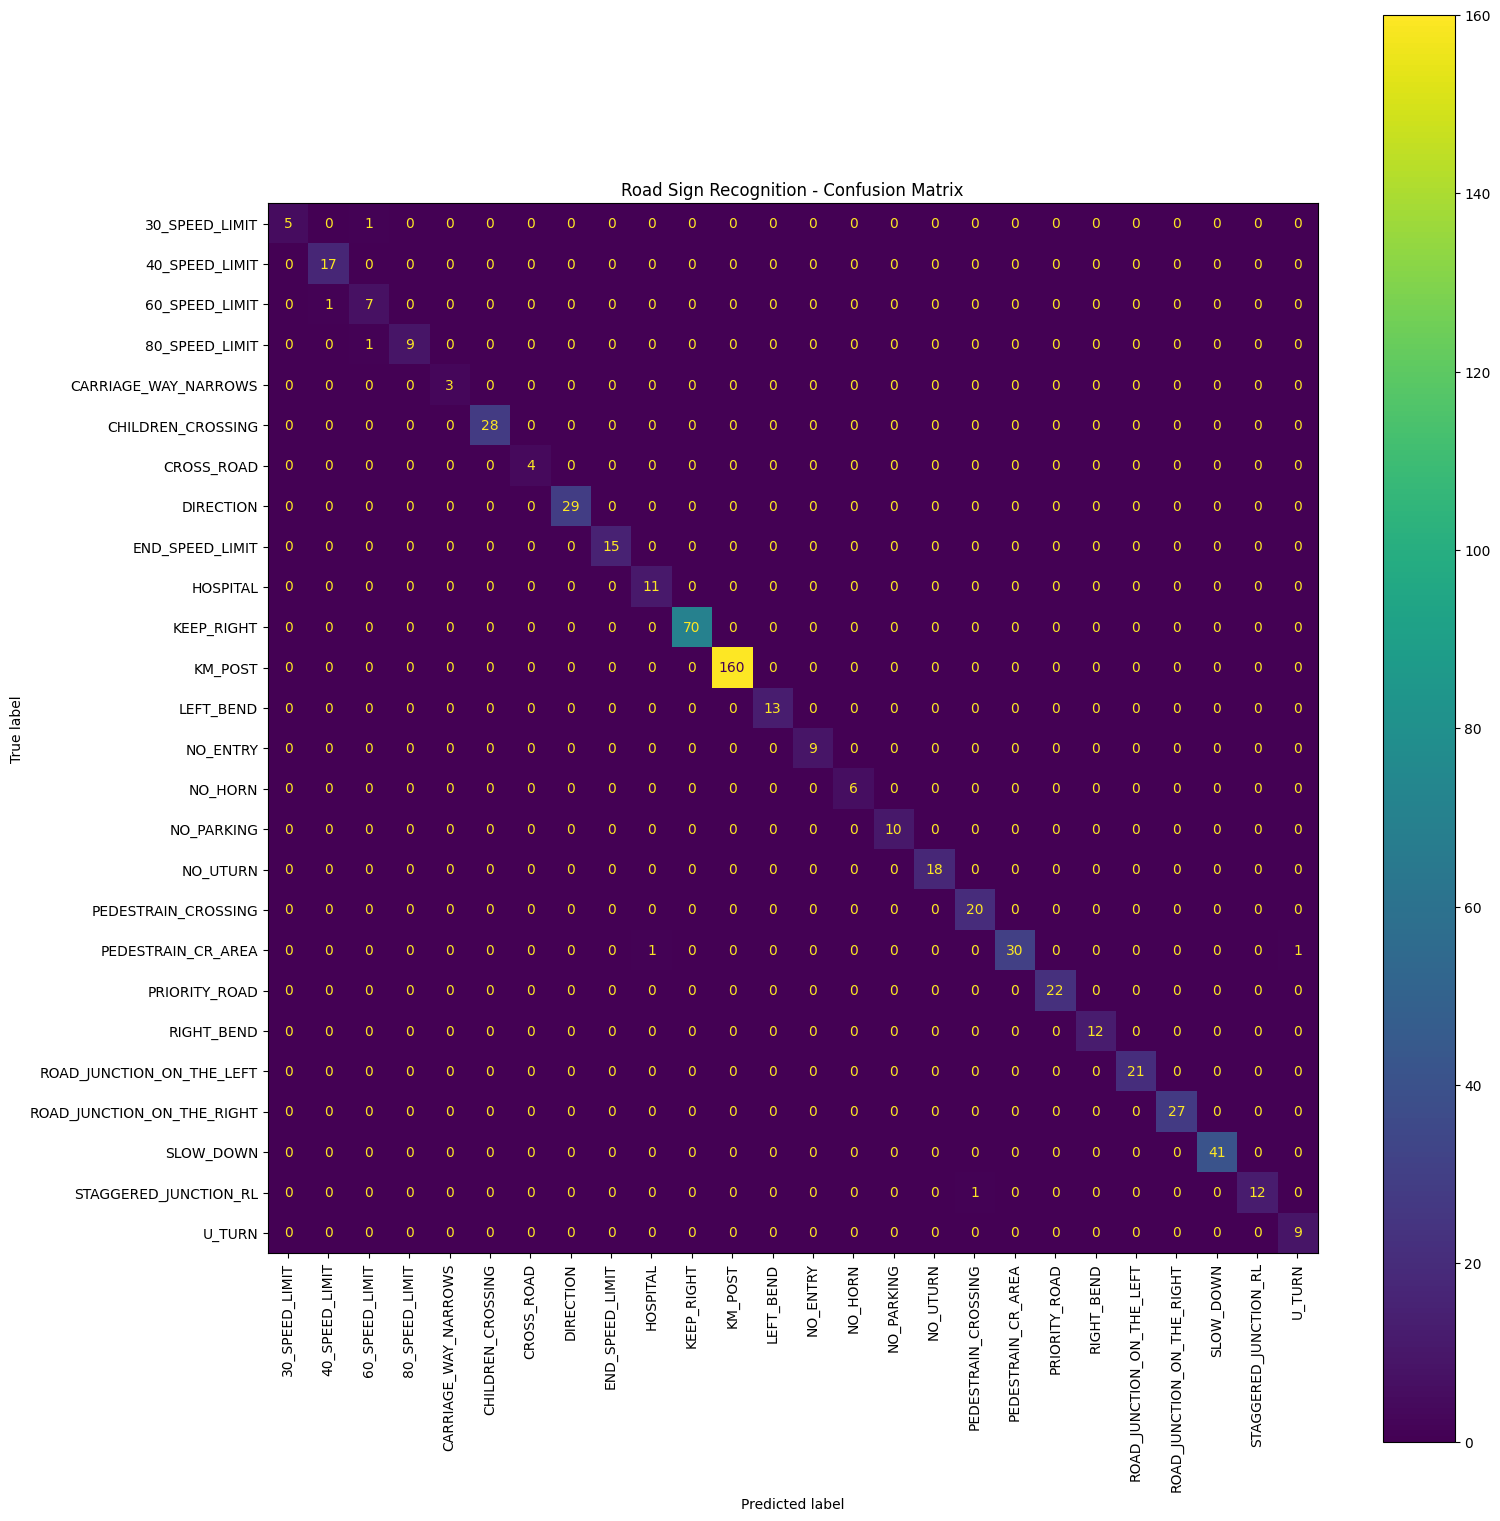

In [26]:
# ============================================
# CONFUSION MATRIX
# ============================================

import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images, verbose=0)
    predicted_classes = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)

# Create confusion matrix
cm = confusion_matrix(
    y_true,
    y_pred,
    labels=range(len(class_names))
)

fig, ax = plt.subplots(figsize=(16, 16))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    xticks_rotation=90,
    values_format="d"
)

plt.title("Road Sign Recognition - Confusion Matrix")
plt.tight_layout()
plt.show()

In [27]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print(report)

                            precision    recall  f1-score   support

            30_SPEED_LIMIT     1.0000    0.8333    0.9091         6
            40_SPEED_LIMIT     0.9444    1.0000    0.9714        17
            60_SPEED_LIMIT     0.7778    0.8750    0.8235         8
            80_SPEED_LIMIT     1.0000    0.9000    0.9474        10
      CARRIAGE_WAY_NARROWS     1.0000    1.0000    1.0000         3
         CHILDREN_CROSSING     1.0000    1.0000    1.0000        28
                CROSS_ROAD     1.0000    1.0000    1.0000         4
                 DIRECTION     1.0000    1.0000    1.0000        29
           END_SPEED_LIMIT     1.0000    1.0000    1.0000        15
                  HOSPITAL     0.9167    1.0000    0.9565        11
                KEEP_RIGHT     1.0000    1.0000    1.0000        70
                   KM_POST     1.0000    1.0000    1.0000       160
                 LEFT_BEND     1.0000    1.0000    1.0000        13
                  NO_ENTRY     1.0000    1.0000

In [28]:
# ============================================
# SAVE TRAINED CNN MODEL
# ============================================

model_path = "/content/drive/MyDrive/Road_Sign_Recognition_CNN/models/road_sign_cnn.keras"

model.save(model_path)

print("Model saved successfully!")
print("Location:", model_path)

Model saved successfully!
Location: /content/drive/MyDrive/Road_Sign_Recognition_CNN/models/road_sign_cnn.keras
